<div align="center">
    
# Mortgage Risk Modeling
# 3.0 Exploratory Data Analysis

## 3.1 Table of Contents<a id='3.1_Table_of_Contents'></a>
* [3.1 Table of Contents](#3.1_Table_of_Contents)
* [3.2 Introduction](#3.2_Introduction)
* [3.3 Library Imports](#3.3_Library_Imports)
* [3.4 Data Loading](#3.4_Data_Loading)
* [3.5 Feature Analysis](#3.5_Feature_Analysis)
  * [3.5.1 Numerical Features](#3.5.1_Numerical_Features)
  * [3.5.2 Categorical Features](#3.5.2_Categorical_Features)
  * [3.5.3 Time Series Analysis](#3.5.3_Time_Series_Analysis)
  * [3.5.4 Score & LTV Risk Analysis](#3.5.4_Score_and_LTV_Risk_Analysis)
* [3.6 Summary](#3.6_Summary)


## 3.2 Introduction<a id='3.2_Introduction'></a>

This notebook performs Exploratory Data Analysis (EDA) on the cleaned mortgage dataset. Following the data wrangling phase, we now aim to uncover the underlying patterns and risk drivers that influence loan performance.

The primary objectives of this analysis are:

Understand Feature Distributions: Analyze the spread and central tendencies of key risk factors like Interest Rates (ORIG_RATE), Debt-to-Income ratios (DTI), and Credit Scores (CSCORE_B).

Detect Relationships & Correlations: Identify which variables move together—for example, how Loan-to-Value (OLTV) correlates with the likelihood of delinquency.

Identify Patterns & Trends: Observe how loan characteristics fluctuate over time (ACT_PERIOD) or across different geographical regions (States).

Risk Profile Segmentation: Compare the behaviors of different borrower groups to identify high-risk segments before moving into formal feature engineering.

## 3.3 Library Imports<a id='3.3_Library_Imports'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math

In [2]:
# display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Plot style
sns.set(style="white", font_scale=1.2)

## 3.4 Data Loading<a id='3.4_Data_Loading'></a>

In [3]:
# Load preprocessed data from previous step
df = pd.read_csv('../data/processed/mrm_data_01_cleaned.csv')

print(f"Shape of df: {df.shape}")
df.head()

Shape of df: (104871, 29)


,LOAN_ID,ACT_PERIOD,CHANNEL,ORIG_RATE,ORIG_UPB,ORIG_TERM,ORIG_DATE,FIRST_PAY,OLTV,OCLTV,NUM_BO,DTI,CSCORE_B,CSCORE_C,FIRST_FLAG,PURPOSE,PROP,NO_UNITS,OCC_STAT,STATE,MSA,MI_PCT,MI_TYPE,HOMEREADY_PROGRAM_INDICATOR,RELOCATION_MORTGAGE_INDICATOR,PROPERTY_INSPECTION_WAIVER_INDICATOR,HIGH_BALANCE_LOAN_INDICATOR,PREPAID_FLAG,DEFAULT_FLAG
0,98836742,2020-01-01,C,3.375,308000.0,180,2019-08-01,2019-10-01,75,75,1,38.0,796.0,0.0,Y,P,SF,1,P,MI,19820,0.0,0.0,N,N,W,N,1,0
1,98836743,2020-01-01,R,3.625,207000.0,240,2019-12-01,2020-02-01,66,66,2,25.0,806.0,797.0,N,R,SF,1,P,OH,17140,0.0,0.0,N,N,A,N,1,0
2,98836744,2020-01-01,R,3.625,215000.0,240,2020-01-01,2020-03-01,73,73,2,42.0,745.0,785.0,N,R,SF,1,P,OH,18140,0.0,0.0,N,N,A,N,1,0
3,98836781,2020-01-01,R,3.750,286000.0,360,2020-01-01,2020-03-01,79,79,2,39.0,789.0,794.0,N,R,SF,1,P,CO,17820,0.0,0.0,N,N,W,N,0,0
4,98836789,2020-01-01,R,3.990,222000.0,360,2019-12-01,2020-02-01,78,78,2,43.0,681.0,769.0,N,R,SF,1,P,MI,19820,0.0,0.0,Y,N,W,N,0,0


In [4]:
# Calculate the overall portfolio rates
default_rate = df['DEFAULT_FLAG'].mean() * 100
prepaid_rate = df['PREPAID_FLAG'].mean() * 100

print(f"Overall Default Rate: {default_rate:.2f}%")
print(f"Overall Prepaid Rate: {prepaid_rate:.2f}%")

Overall Default Rate: 2.35%
Overall Prepaid Rate: 50.89%


## 3.5 Feature Analysis<a id='3.5_Feature_Analysis'></a>

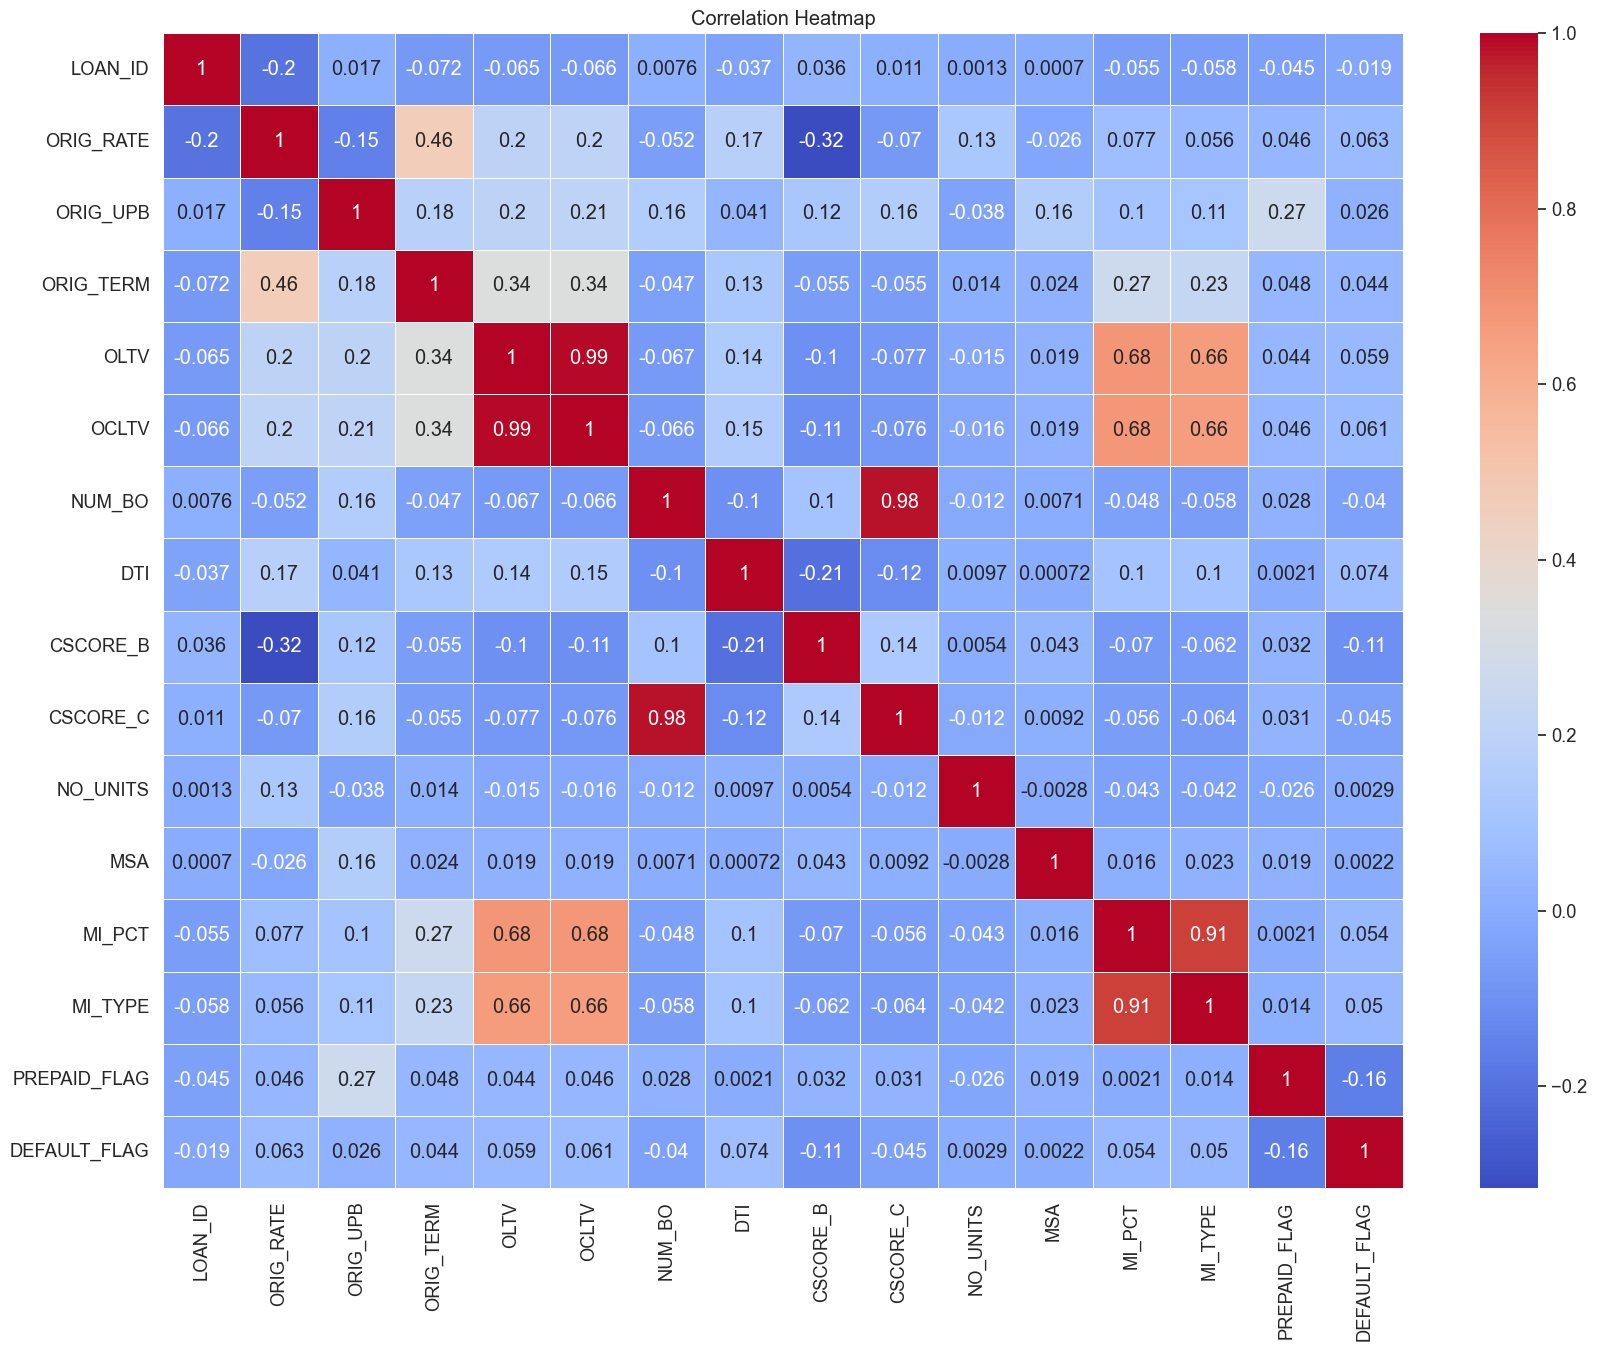

In [5]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

**Highly Correlated features:**

* OLTV vs. OCLTV ($0.99$):

    Keep OLTV (Original Loan-to-Value). Combined LTV (OCLTV) only differs if there is a second mortgage, which is rare in this sample.

* CSCORE_C vs. NUM_BO ($0.98$):

    Keep NUM_BO to capture the risk impact of a second borrower without the bias of the 0 filler values used in CSCORE_C.

* MI_PCT vs. MI_TYPE ($0.91$):

    Keep MI_TYPE to capture the categorical risk impact of loan insurance while removing the redundant MI_PCT to minimize multicollinearity.

In [6]:
# List of redundant columns to remove based on correlation analysis
cols_to_exclude = ['OCLTV','CSCORE_C','MI_PCT']

# Drop the columns from the dataframe
df.drop(columns=cols_to_exclude, inplace=True, errors='ignore')

# Display result
print(f"Shape of df: {df.shape}")

Shape of df: (104871, 26)


### 3.5.1 Numerical Features<a id='3.5.1_Numerical_Features'></a>


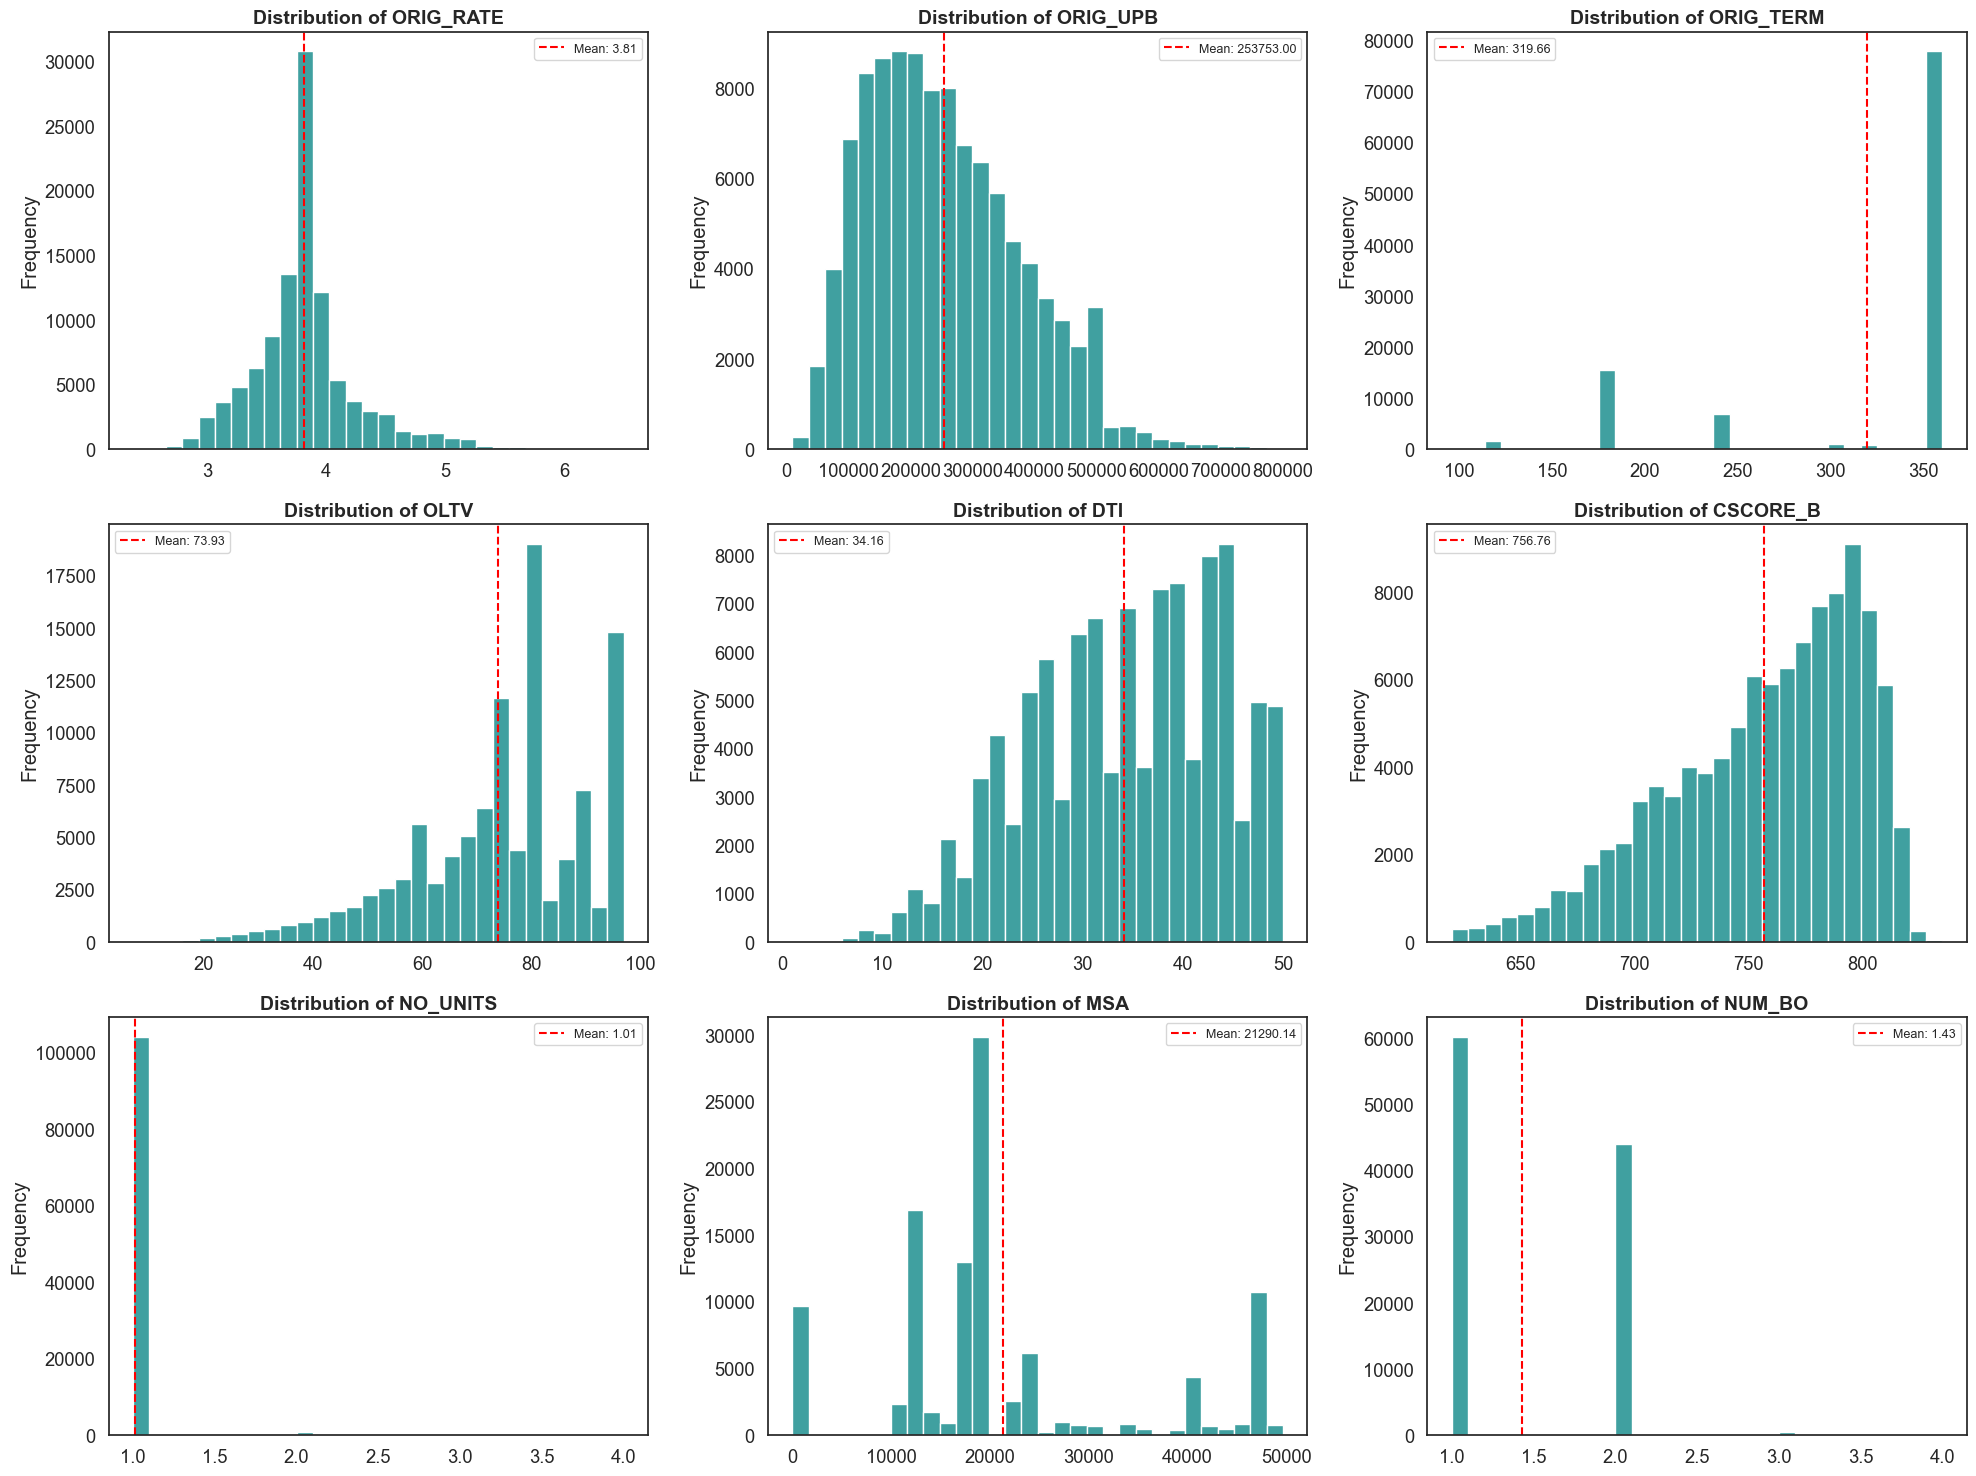

In [7]:
# Select numerical features
num_features = ['ORIG_RATE','ORIG_UPB','ORIG_TERM','OLTV','DTI','CSCORE_B','NO_UNITS','MSA', 'NUM_BO']

# Plot distributions of numerical features
n_cols = 3
n_rows = math.ceil(len(num_features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df[col], ax=axes[i], color='teal', bins=30)
    
    # Add mean lines
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Loan Characteristics**

* Loan Size (ORIG_UPB): Concentrated between 150k–350k with a right tail extending to 800k.

* Interest Rates (ORIG_RATE): Heavily spiked at 3.5%–4.0%, reflecting the early 2020 low-rate environment.

* Loan Term (ORIG_TERM): Dominated by 30-year fixed (360 months) with a small 15-year cluster.

**Borrower Risk Profile**

* Credit Scores (CSCORE_B): Left-skewed (high quality) with a peak between 760–800.

* Debt-to-Income (DTI): Most borrowers are leveraged near the industry ceiling, peaking at 35%–45%.

* Loan-to-Value (OLTV): Significant spikes at 80% (equity threshold) and 95% (low down-payment).

**Property & Borrowers**

* Units (NO_UNITS): Overwhelmingly single-unit properties.

* Borrowers (NUM_BO): Evenly split between single and co-borrower applications.

### 3.5.2 Categorical Features<a id='3.5.2_Categorical_Features'></a>


In [8]:
# Define a function to plot counts and risk rates by category
def plot_risk_indicators(dataframe, feature_list, n_cols=3):
    n_rows = math.ceil(len(feature_list) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 8 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(feature_list):
        # Prepare Data
        stats = dataframe.groupby(col).agg({
            'LOAN_ID': 'count',
            'DEFAULT_FLAG': 'mean',
            'PREPAID_FLAG': 'mean'
        })
        
        stats['DEFAULT_FLAG'] *= 100
        stats['PREPAID_FLAG'] *= 100
        stats = stats.sort_values(by='LOAN_ID', ascending=False)
        x_cats = stats.index.astype(str)

        # --- AXIS 1: Volume (Background Bars) ---
        ax_vol = axes[i]
        bars = sns.barplot(x=x_cats, y=stats['LOAN_ID'], ax=ax_vol, 
                           color='lightgrey', alpha=0.7)
        
        ax_vol.set_ylabel('')
        ax_vol.set_yticks([])
        ax_vol.set_yticklabels([])
        ax_vol.set_ylim(0, stats['LOAN_ID'].max() * 1.4) 
        ax_vol.set_title(f'Risk Analysis by {col}', fontweight='bold', pad=30)

        # Standard Count Labels
        for p in bars.patches:
            ax_vol.annotate(f'{int(p.get_height()):,}', 
                            (p.get_x() + p.get_width() / 2., p.get_height()), 
                            ha='center', va='bottom', 
                            xytext=(0, 8), textcoords='offset points', 
                            fontsize=12, fontweight='bold', color='black')

        # --- AXIS 2: Default Rate (Left Overlay) ---
        ax_def = ax_vol.twinx()
        ax_def.yaxis.set_label_position('left')
        ax_def.yaxis.set_ticks_position('left')

        sns.lineplot(x=range(len(stats)), y=stats['DEFAULT_FLAG'], ax=ax_def, 
                     color='red', marker='o', markersize=10, linewidth=4, label='Default Rate %')
        
        ax_def.set_ylabel('Default Rate (%)', color='red', fontweight='bold')
        ax_def.set_ylim(0, 10) 
        ax_def.tick_params(axis='y', labelcolor='red')
        ax_def.grid(False)

        # --- AXIS 3: Prepaid Rate (Right Overlay) ---
        ax_pre = ax_vol.twinx()
        sns.lineplot(x=range(len(stats)), y=stats['PREPAID_FLAG'], ax=ax_pre, 
                     color='blue', marker='s', markersize=10, linewidth=4, label='Prepaid Rate %')
        
        ax_pre.set_ylabel('Prepaid Rate (%)', color='blue', fontweight='bold')
        ax_pre.set_ylim(0, 100) 
        ax_pre.tick_params(axis='y', labelcolor='blue')
        ax_pre.grid(False)

        # Legend Handling
        h1, l1 = ax_def.get_legend_handles_labels()
        h2, l2 = ax_pre.get_legend_handles_labels()
        ax_pre.legend(h1 + h2, l1 + l2, loc='upper right', frameon=True, fontsize=10)

        # Formatting X-Axis
        ax_vol.set_xlabel(f'{col}', fontweight='bold')
        ax_vol.tick_params(axis='x', rotation=30)

    # Final Cleanup
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


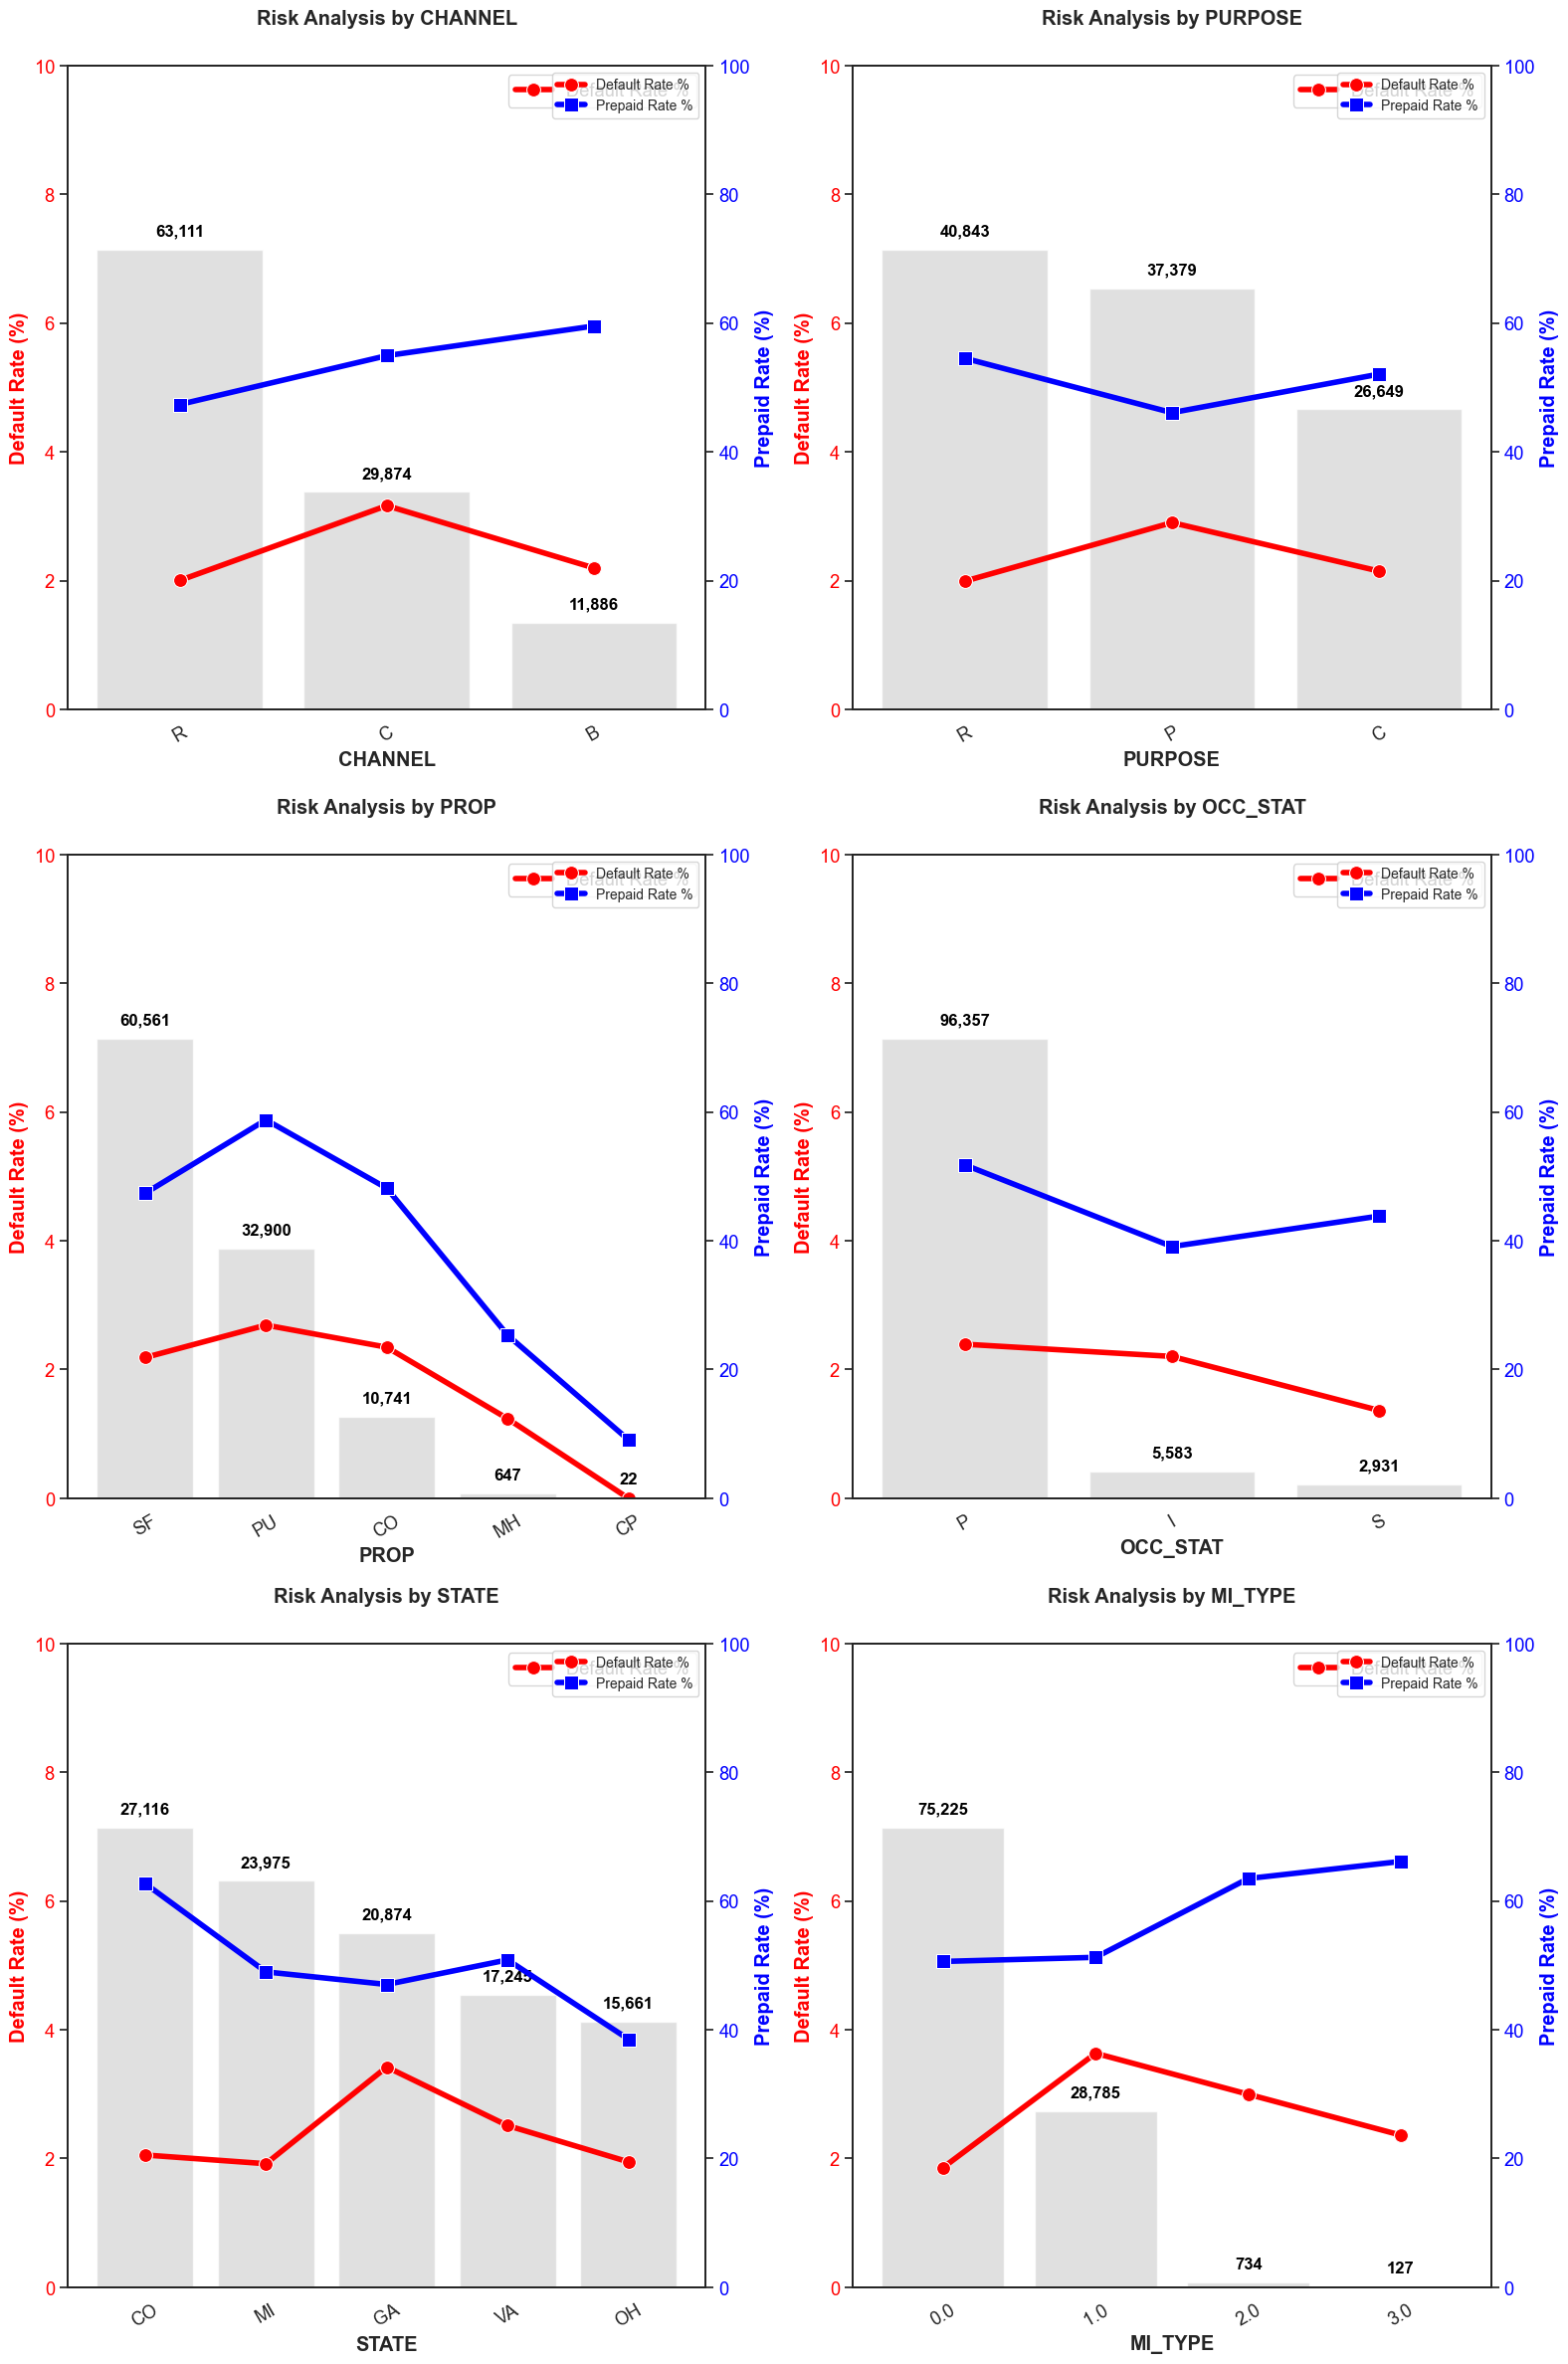

In [9]:
# Plot Categorical features
features = ['CHANNEL', 'PURPOSE', 'PROP', 'OCC_STAT', 'STATE', 'MI_TYPE']

plot_risk_indicators(df, features, n_cols=2)

**Overall:**
* For most categorical features, prepayment rates fall between 40–60% and default rates fall between 1–4% across most segments. There is no single dominant segment that drives the risk rates, suggesting that performance is influenced by a combination of broad economic factors and specific borrower characteristics.

**Property Segment Insights:**
* Manufactured Housing (MH) and Co-operatives (CP) are identified as low-velocity outliers, exhibiting lower rates of both default and prepayment compared to the broader portfolio.

**Insurance Risk Multiplier:**
* Mortgage Insurance status is a key credit signal; Type 1 (Primary MI) exhibits a significantly higher default rate than Type 0 (No MI), despite both groups showing nearly identical prepayment sensitivity.

**Regional Performance:**
* Geographic analysis identifies Georgia (GA) and Michigan (MI) as the high and low bounds for default risk, while Colorado (CO) and Ohio (OH) represent the extremes for prepayment behavior.

**Purpose of loans:**
* C (Cash-out Refinance)
* P (Purchase)
* R (Rate/Term Refinance)

**Type of Property:**
* CO: Condominium
* CP: Cooperative Housing (Co-op)
* MH: Manufactured Housing
* PU: Planned Unit Development (PUD)
* SF: Single-Family Residence


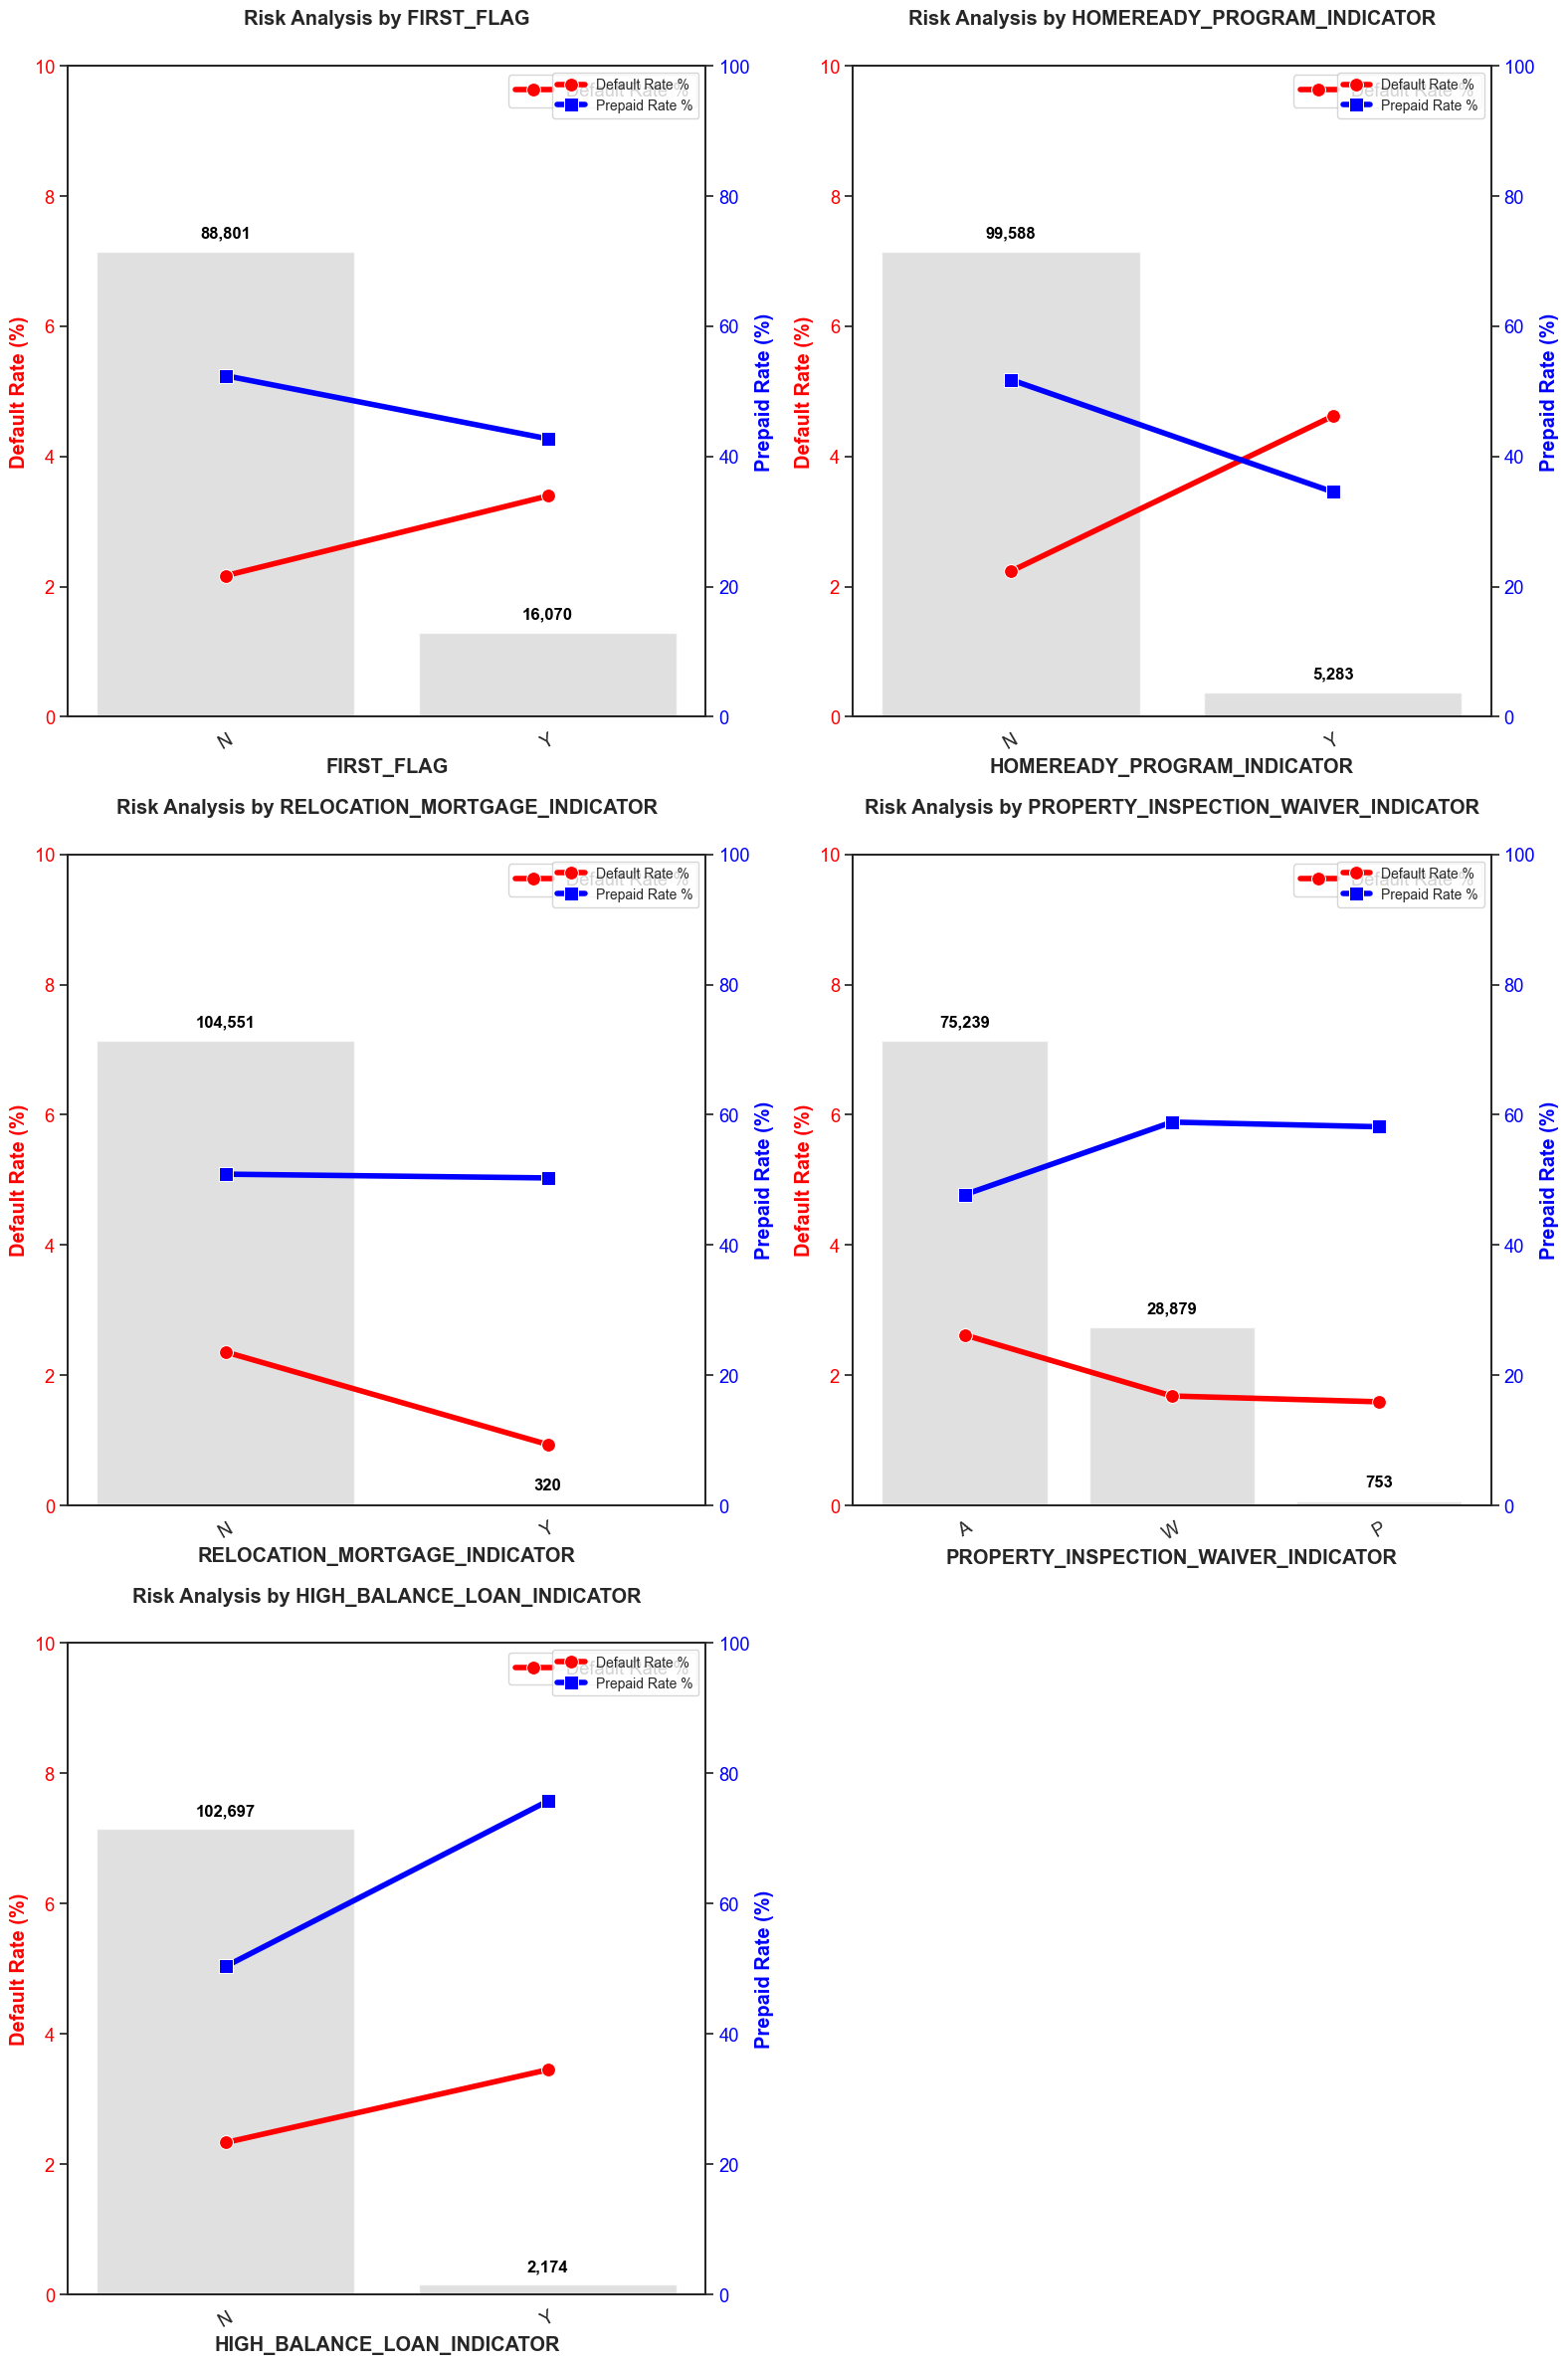

In [12]:
# Plot indicator features
features = ['FIRST_FLAG','HOMEREADY_PROGRAM_INDICATOR','RELOCATION_MORTGAGE_INDICATOR',
            'PROPERTY_INSPECTION_WAIVER_INDICATOR','HIGH_BALANCE_LOAN_INDICATOR']

plot_risk_indicators(df, features, n_cols=2)

All five indicators show meaningful differences relative to the average default rate of 2.35%. The HomeReady program indicator has the highest default rate, at around 5%, while the relocation indicator has the lowest, at about 1%. The remaining indicators fall between these two levels. This suggests that borrower or program type is associated with different levels of credit risk, and that some loan segments may be more vulnerable to financial stress than others.

Relative to the overall prepaid rate of 50.89%, the high-balance loan indicator has the highest prepayment rate, at more than 70%, while the HomeReady program indicator has the lowest, at below 40%. This pattern suggests that high-balance borrowers may have greater financial flexibility or stronger refinancing capacity, leading to faster payoff behavior. In contrast, HomeReady borrowers appear less likely to prepay and more likely to remain exposed to credit risk over time.

### 3.5.3 Time Series Analysis<a id='3.5.3_Time_Series_Analysis'></a>


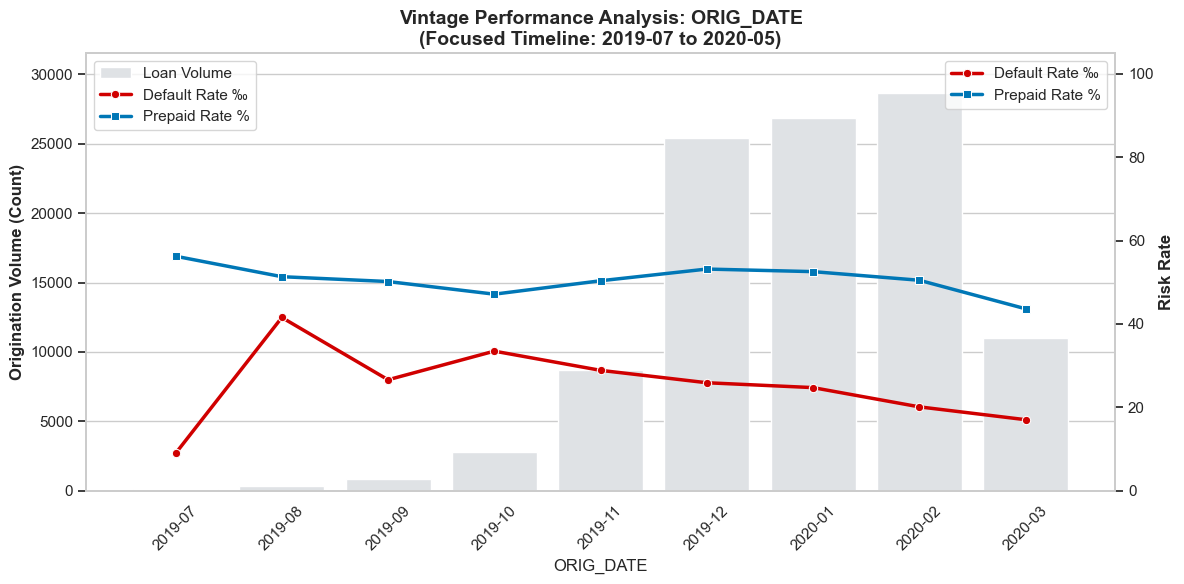

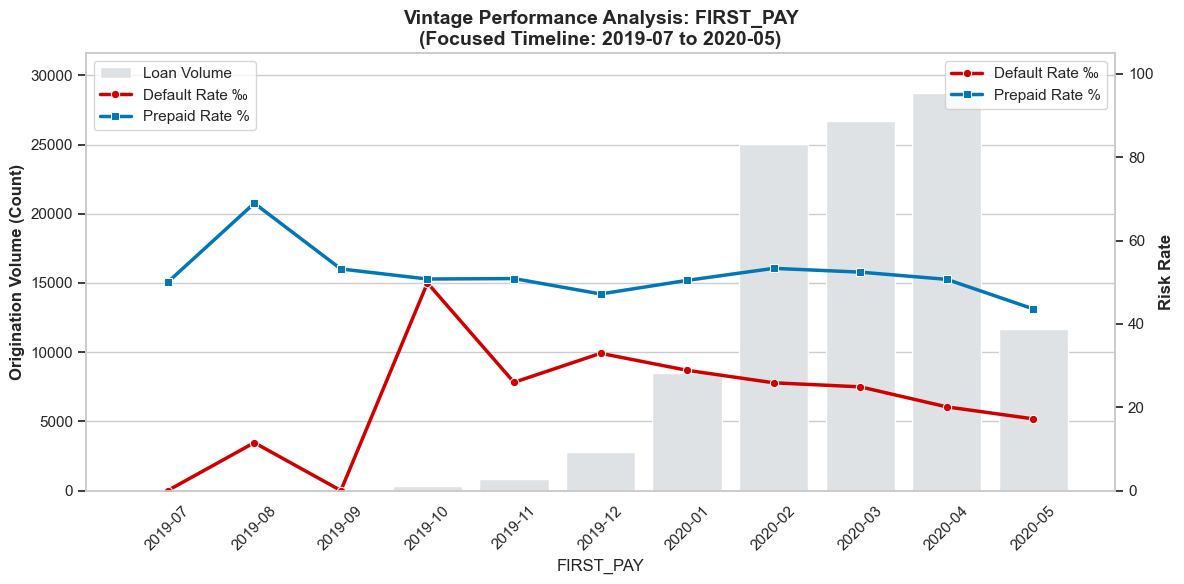

In [13]:
# Define time series features
features = ['ORIG_DATE', 'FIRST_PAY']
sns.set(style="whitegrid")

for col in features:
    # 1. Aggregate ALL data first
    stats = df.groupby(col).agg({
        'LOAN_ID': 'count',
        'DEFAULT_FLAG': 'mean',
        'PREPAID_FLAG': 'mean'
    }).sort_index()

    # Convert to percentages
    stats['DEFAULT_FLAG'] *= 1000
    stats['PREPAID_FLAG'] *= 100
    
    # 2. ZOOM IN FOR PLOTTING ONLY (Focus on 2019-07 to 2020-05)
    # This keeps the training data safe but cleans the visual
    plot_stats = stats.loc['2019-07-01':'2020-05-31'].copy()
    
    # Format labels for the X-axis
    x_labels = pd.to_datetime(plot_stats.index).strftime('%Y-%m')

    # 3. Create the plot
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Volume Bars (Primary Axis)
    sns.barplot(x=x_labels, y=plot_stats['LOAN_ID'], ax=ax1, color='#dee2e6', label='Loan Volume')
    ax1.set_ylabel('Origination Volume (Count)', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    ax1.set_ylim(0, plot_stats['LOAN_ID'].max() * 1.1)

    # Risk Lines (Secondary Axis)
    ax2 = ax1.twinx()
    
    sns.lineplot(x=range(len(plot_stats)), y=plot_stats['DEFAULT_FLAG'], ax=ax2, 
                 color='#d00000', marker='o', linewidth=2.5, label='Default Rate ‰')
    
    sns.lineplot(x=range(len(plot_stats)), y=plot_stats['PREPAID_FLAG'], ax=ax2, 
                 color='#0077b6', marker='s', linewidth=2.5, label='Prepaid Rate %')

    # 4. Polish and Scale
    ax2.set_ylabel('Risk Rate', fontweight='bold')
    ax2.set_ylim(0, 105) # Keeps scale consistent for prepayments
    ax2.grid(False)

    plt.title(f'Vintage Performance Analysis: {col}\n(Focused Timeline: 2019-07 to 2020-05)', 
              fontsize=14, fontweight='bold')
    
    # Combined Legend
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc='upper left')

    plt.tight_layout()
    plt.show()

Originations are heavily concentrated between November 2019 and March 2020, with a consistent 2-month lag before the first payment. Both Default and Prepaid rates show small fluctuations across the core months, suggesting the time of origination is not a major risk differentiator for this cohort. The model should prioritize borrower-specific features (Credit Score, DTI) over temporal ones to predict outcomes. Data from originations prior to July 2019 were excluded from the analysis due to insufficient volume, which prevents statistically significant risk comparisons for those earlier periods.

### 3.5.4 Score & LTV Risk Analysis<a id='3.5.4_Score_and_LTV_Risk_Analysis'></a>


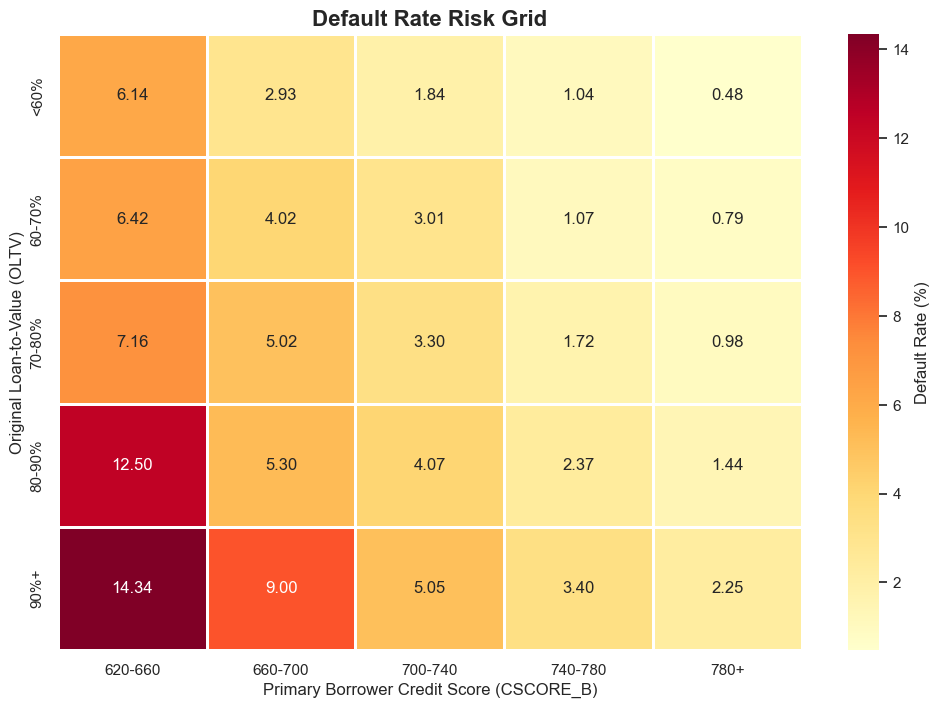

In [14]:
# Define bins for Credit Score and LTV
score_bins = [620, 660, 700, 740, 780, 850]
score_labels = ['620-660', '660-700', '700-740', '740-780', '780+']

ltv_bins = [0, 60, 70, 80, 90, 100]
ltv_labels = ['<60%', '60-70%', '70-80%', '80-90%', '90%+']

# Create a DataFrame for Pivot Table
df_plot = df[['CSCORE_B', 'OLTV', 'DEFAULT_FLAG','PREPAID_FLAG']].copy()
df_plot['Score_Group'] = pd.cut(df_plot['CSCORE_B'], bins=score_bins, labels=score_labels)
df_plot['LTV_Group'] = pd.cut(df_plot['OLTV'], bins=ltv_bins, labels=ltv_labels)

# Create Pivot Table of Default Rates (%)
heatmap_data = df_plot.pivot_table(
    index='LTV_Group', 
    columns='Score_Group', 
    values='DEFAULT_FLAG', 
    aggfunc='mean',
    observed=True
) * 100

#Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".2f", 
    cmap='YlOrRd', 
    linewidths=2, 
    cbar_kws={'label': 'Default Rate (%)'}
)

plt.title('Default Rate Risk Grid', fontsize=16, fontweight='bold')
plt.xlabel('Primary Borrower Credit Score (CSCORE_B)', fontsize=12)
plt.ylabel('Original Loan-to-Value (OLTV)', fontsize=12)
plt.show()

- **Credit Quality (CSCORE_B)**

There is a clear inverse relationship between credit scores and default risk. While the portfolio is concentrated in the 760+ range, borrowers with scores below 660 exhibit default rates significantly above the portfolio average, confirming FICO as a primary risk separator.

- **Equity and Leverage (OLTV)**

Default risk escalates sharply as the Loan-to-Value (LTV) ratio exceeds 80%. The "spike" in defaults at the 95% LTV mark highlights the heightened sensitivity of low-equity borrowers to financial stress compared to those with a 20%+ down payment.

- **Debt-to-Income (DTI)**

A positive correlation exists between DTI and default rates. Borrowers with DTI ratios above 45% show elevated risk profiles, suggesting that high monthly debt obligations are a secondary but critical driver of credit distress in this cohort.

- **Loan Balance (ORIG_UPB)**

Interestingly, mid-tier loan balances show the highest stability. Both extremely low and extremely high balance loans exhibit slightly higher default volatility, likely reflecting different borrower demographics at the tail ends of the housing market.

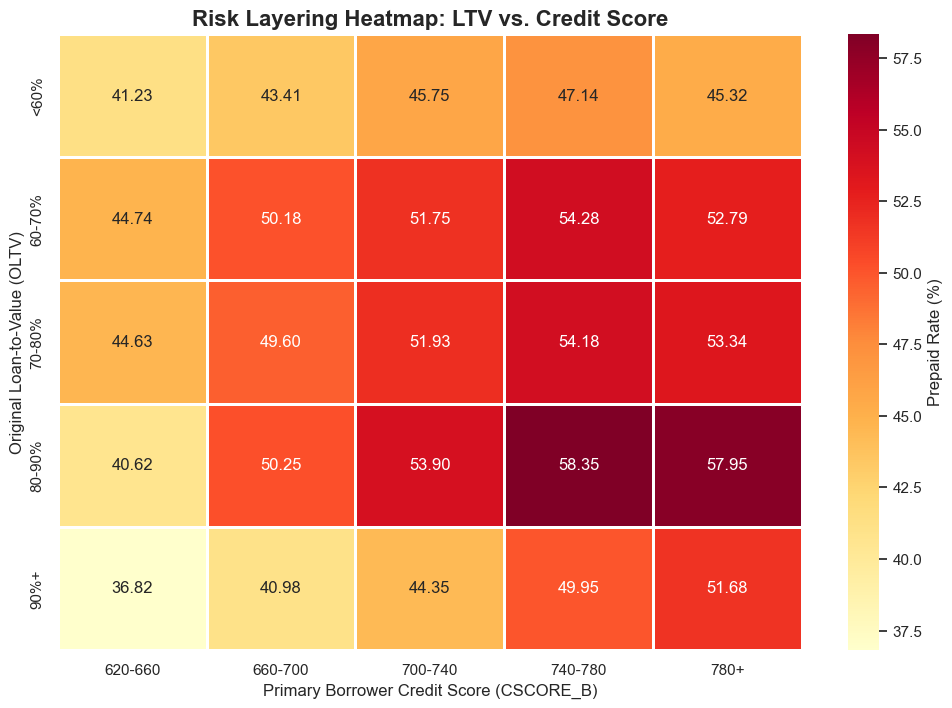

In [15]:
# Create Pivot Table of Prepaid Rates (%)
heatmap_data = df_plot.pivot_table(
    index='LTV_Group', 
    columns='Score_Group', 
    values='PREPAID_FLAG', 
    aggfunc='mean',
    observed=True
) * 100

# Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".2f", 
    cmap='YlOrRd', 
    linewidths=2, 
    cbar_kws={'label': 'Prepaid Rate (%)'}
)

plt.title('Risk Layering Heatmap: LTV vs. Credit Score', fontsize=16, fontweight='bold')
plt.xlabel('Primary Borrower Credit Score (CSCORE_B)', fontsize=12)
plt.ylabel('Original Loan-to-Value (OLTV)', fontsize=12)
plt.show()

## 3.6 Summary<a id='3.6_Summary'></a>

**General vs. Specific Trends:**
* For most categorical features, prepayment rates fall between 40–60% and default rates fall between 1–4%. There is no single dominant segment that drives these rates, suggesting that prepayment is largely influenced by broad economic factors (interest rates), while defaults are driven by specific borrower characteristics.

**Property & Insurance Outliers:**
* Manufactured Housing (MH) and Co-operatives (CP) are low-velocity outliers with lower-than-average risk activity. Mortgage Insurance status is a critical credit signal; Type 1 (Primary MI) exhibits significantly higher default risk than Type 0 (No MI), despite having nearly identical prepayment behavior.

**Critical Risk Indicators**: 
* The Forbearance Indicator (F) is the most acute risk signal in the portfolio, with default rates reaching ~31% (10x the baseline). Other high-risk segments include First-time homebuyers and HomeReady participants, who show greater sensitivity to economic volatility.

**Regional Performance:**
* Geographic analysis identifies Georgia (GA) and Michigan (MI) as the high and low bounds for default risk, while Colorado (CO) and Ohio (OH) represent the extremes for prepayment sensitivity.

**Vintage Stability:**
* Origination timing between November 2019 and March 2020 is not a major risk differentiator. This confirms that the model should prioritize borrower-specific features (Credit Score, DTI, OLTV) over temporal ones to predict outcomes for this cohort.

In [16]:
output_path = "../data/processed/mrm_data_02_analyzed.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df.to_csv(output_path, index=False)
print(f"Updated data saved to {output_path}")
print(f"Shape: {df.shape}")

Updated data saved to ../data/processed/mrm_data_02_analyzed.csv
Shape: (104871, 26)
